# CV HW5 - Question 1: Pet Segmentation Full Pipeline

This notebook demonstrates the complete pipeline for the Oxford-IIIT Pet Segmentation task. It uses the modular scripts provided (`dataset.py`, `unet.py`, `train.py`, `utils.py`, `evaluate.py`, `sam_evaluation.py`, `section5_comparison.py`) to train a U-Net, evaluate it, perform error analysis, and compare it with the Segment Anything Model (SAM).

In [2]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt

# Load all functions and classes from the provided scripts
from dataset import get_datasets, visualize_samples, DataLoader, denormalize
from unet import UNet
from utils import BCEDiceLoss, calculate_metrics
from train import train_model
from evaluate import evaluate_model, qualitative_evaluation, error_analysis
from sam_evaluation import evaluate_sam_zero_shot
from section5_comparison import compare_models

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## Task 1, 2, 3: Dataset Preparation and Visualization
First, we load the dataset, apply transformations (resizing, normalizations, and augmentations for the training set), and visualize some samples.

Dataset sizes:
- Train: 2944
- Validation: 736
- Test: 3669

Sample 1 - Unique mask values: [0 1]
Sample 2 - Unique mask values: [0 1]
Sample 3 - Unique mask values: [0 1]
Saved visualization to 'task1_visualization.png'


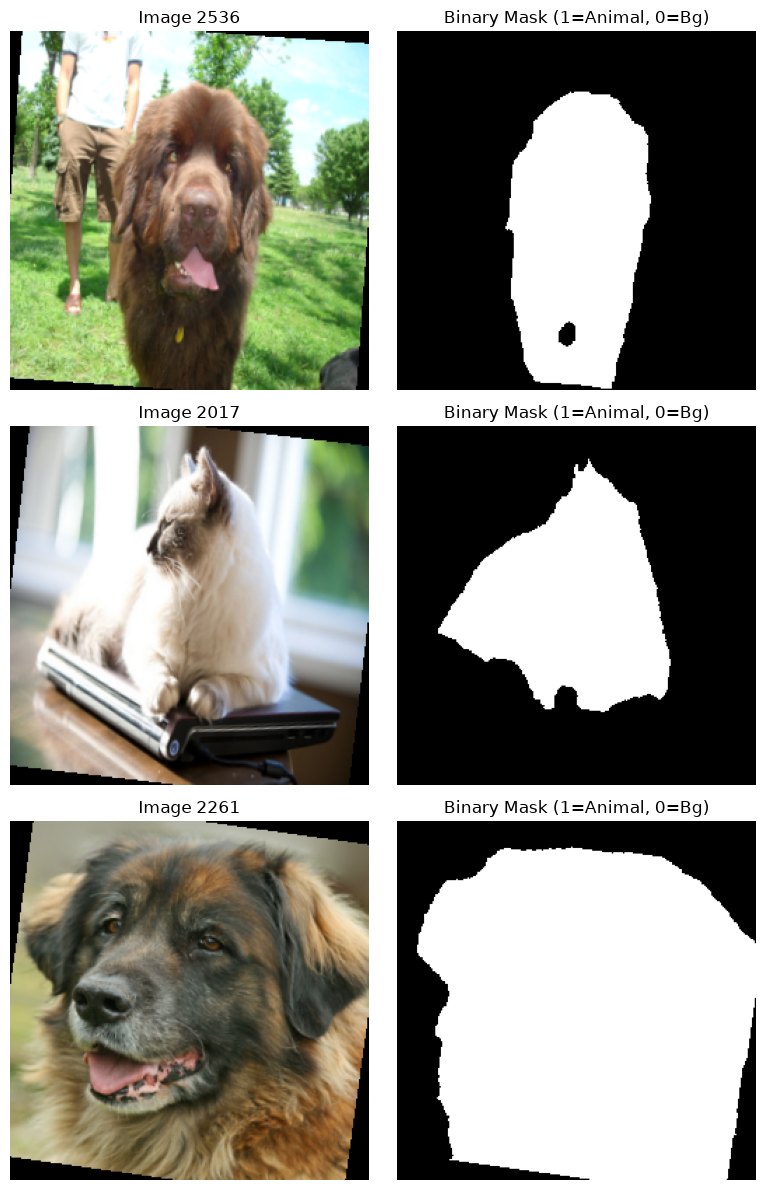

In [3]:
train_set, val_set, test_set = get_datasets(root_dir='./data')

print(f"Dataset sizes:\n- Train: {len(train_set)}\n- Validation: {len(val_set)}\n- Test: {len(test_set)}\n")

# Visualize training samples (includes augmentations)
visualize_samples(train_set, num_samples=3)
plt.show()

## Task 4: U-Net Architecture Verification
We instantiate our U-Net architecture to ensure it correctly processes an input of the required shape.

In [4]:
model = UNet(n_channels=3, n_classes=1).to(device)
dummy_input = torch.randn(1, 3, 256, 256).to(device)
output = model(dummy_input)

print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


## Task 5, 6, 7: Training the U-Net
Train the U-Net model on the Oxford Pet dataset. The `train_model` function handles the training loop, validates after each epoch, saves the best weights (`best_unet_model.pth`), and generates loss/metric curves.

Starting training on device: cuda
Epoch 1/10


Validation: 100%|██████████| 46/46 [00:47<00:00,  1.03s/it]


Train Loss: 0.4834 | Val Loss: 0.4844 | Val IoU: 0.3847 | Val Dice: 0.5324

=> Saved best model
Epoch 2/10


Validation: 100%|██████████| 46/46 [00:45<00:00,  1.00it/s]


Train Loss: 0.4268 | Val Loss: 0.6094 | Val IoU: 0.1240 | Val Dice: 0.1837

Epoch 3/10


...

Train Loss: 0.2781 | Val Loss: 0.2722 | Val IoU: 0.6531 | Val Dice: 0.7746

=> Saved best model
Epoch 9/10


Validation: 100%|██████████| 46/46 [00:45<00:00,  1.01it/s]


Train Loss: 0.2651 | Val Loss: 0.2578 | Val IoU: 0.6809 | Val Dice: 0.7974

=> Saved best model
Epoch 10/10


Validation: 100%|██████████| 46/46 [00:46<00:00,  1.01s/it]


Train Loss: 0.2506 | Val Loss: 0.2435 | Val IoU: 0.6864 | Val Dice: 0.8013

=> Saved best model
Training complete! Generating analysis plots...
Saved training analysis plot to 'task7_training_analysis.png'


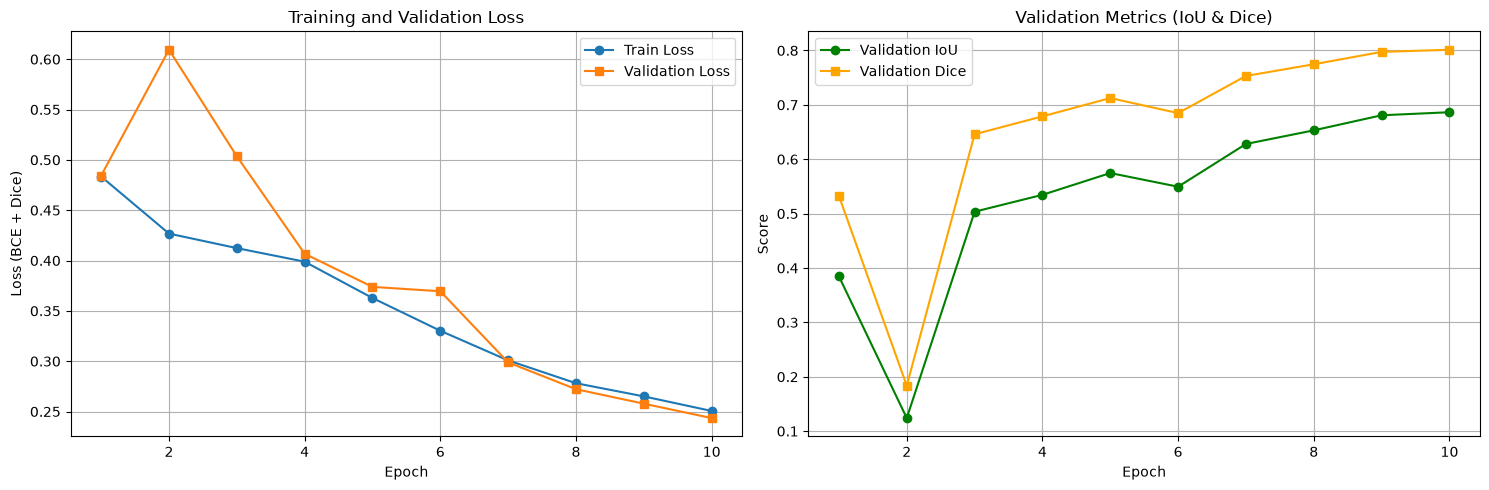

In [5]:
# Note: Reduce num_epochs for a quick test run. 
# For actual training, you might want 10 or more.
trained_model, history = train_model(num_epochs=10, batch_size=16, learning_rate=1e-3, device=device)
plt.show()  # Display the training plots generated in the script

## Task 8, 9, 10: U-Net Evaluation & Error Analysis
Load the best model checkpoint and evaluate it quantitatively (IoU, Dice Score) and qualitatively. We also perform an error analysis by finding the samples where the model struggled the most.

In [6]:
# Quantitave Evaluation
best_model, test_dataset = evaluate_model('best_unet_model.pth', device=device)

Loading datasets...
Loading model from best_unet_model.pth...
Model loaded successfully.

--- Task 8: Quantitative Evaluation ---
Test Set Evaluation => Mean IoU: 0.6956 | Mean Dice Score: 0.8069



--- Task 9: Qualitative Evaluation ---
Saved qualitative results to 'task9_qualitative_eval.png'


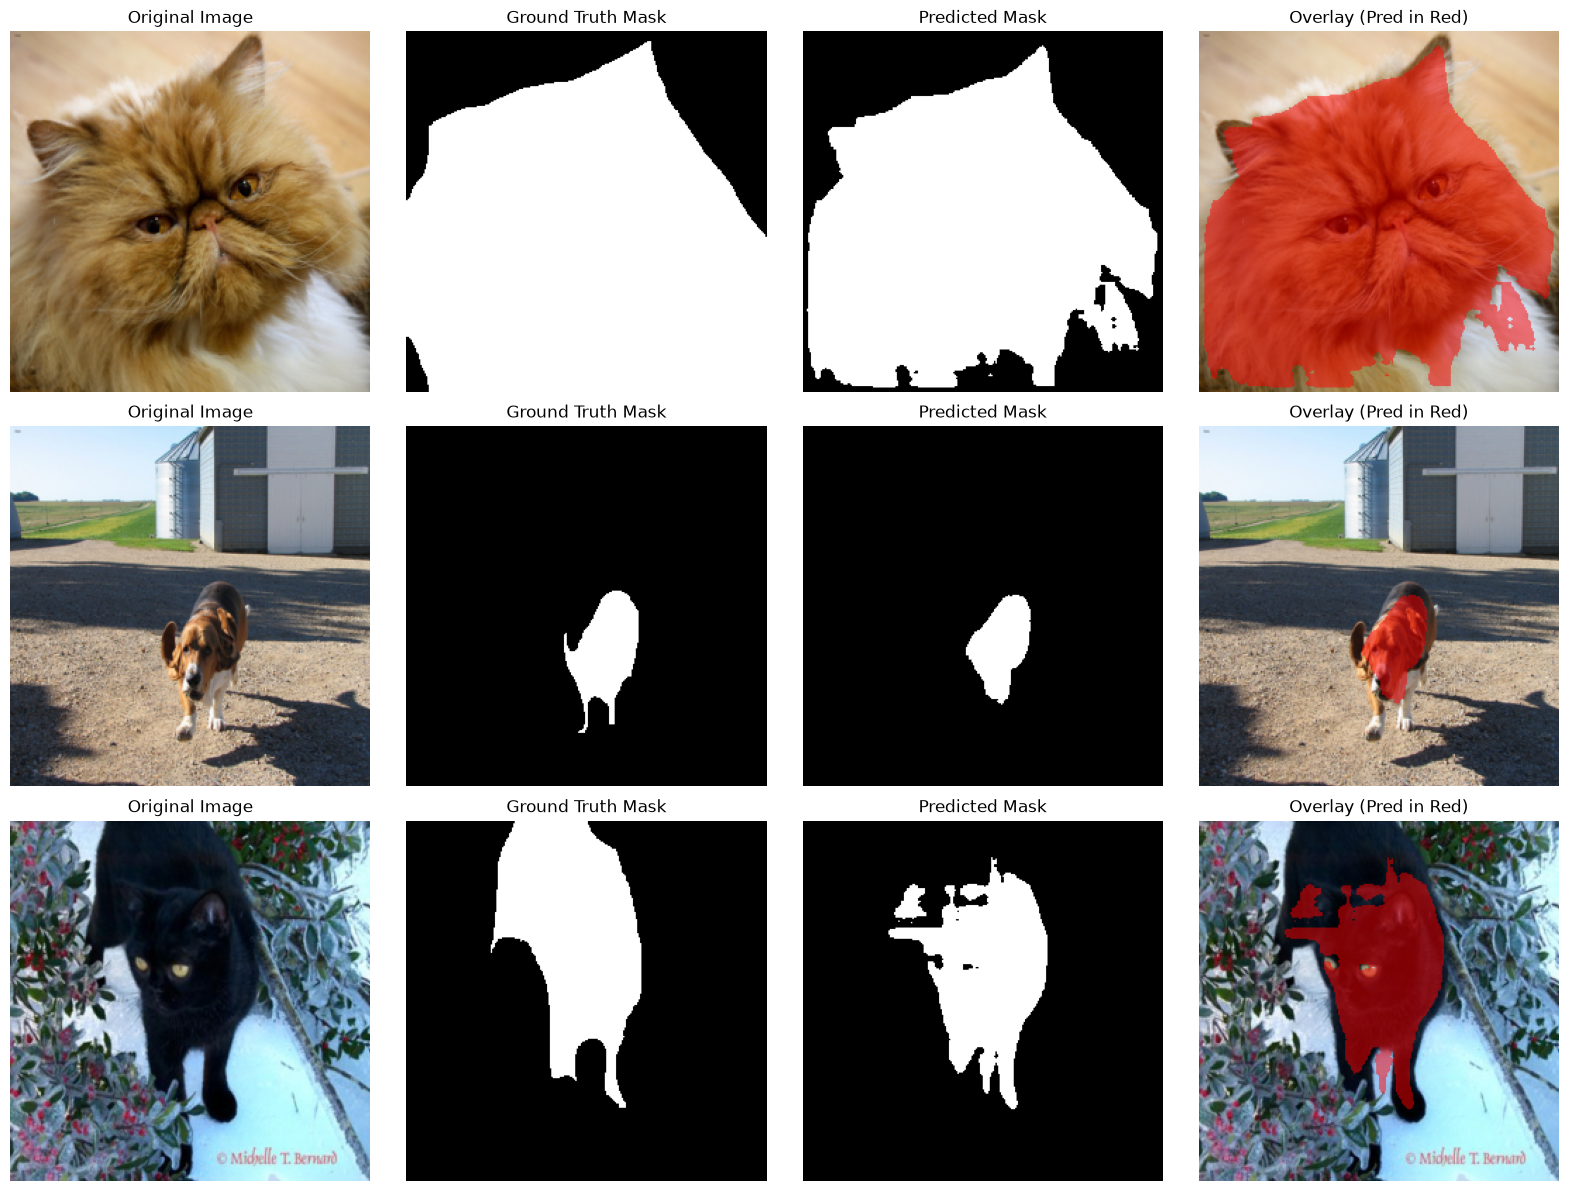

In [7]:
# Qualitative Evaluation
qualitative_evaluation(best_model, test_dataset, device=device, num_samples=3)
plt.show()


--- Task 10: Error Analysis ---
Error Sample 1 saved to plot. IoU: 0.4844, Dice: 0.6526
Error Sample 2 saved to plot. IoU: 0.3819, Dice: 0.5527
Saved error analysis results to 'task10_error_analysis.png'


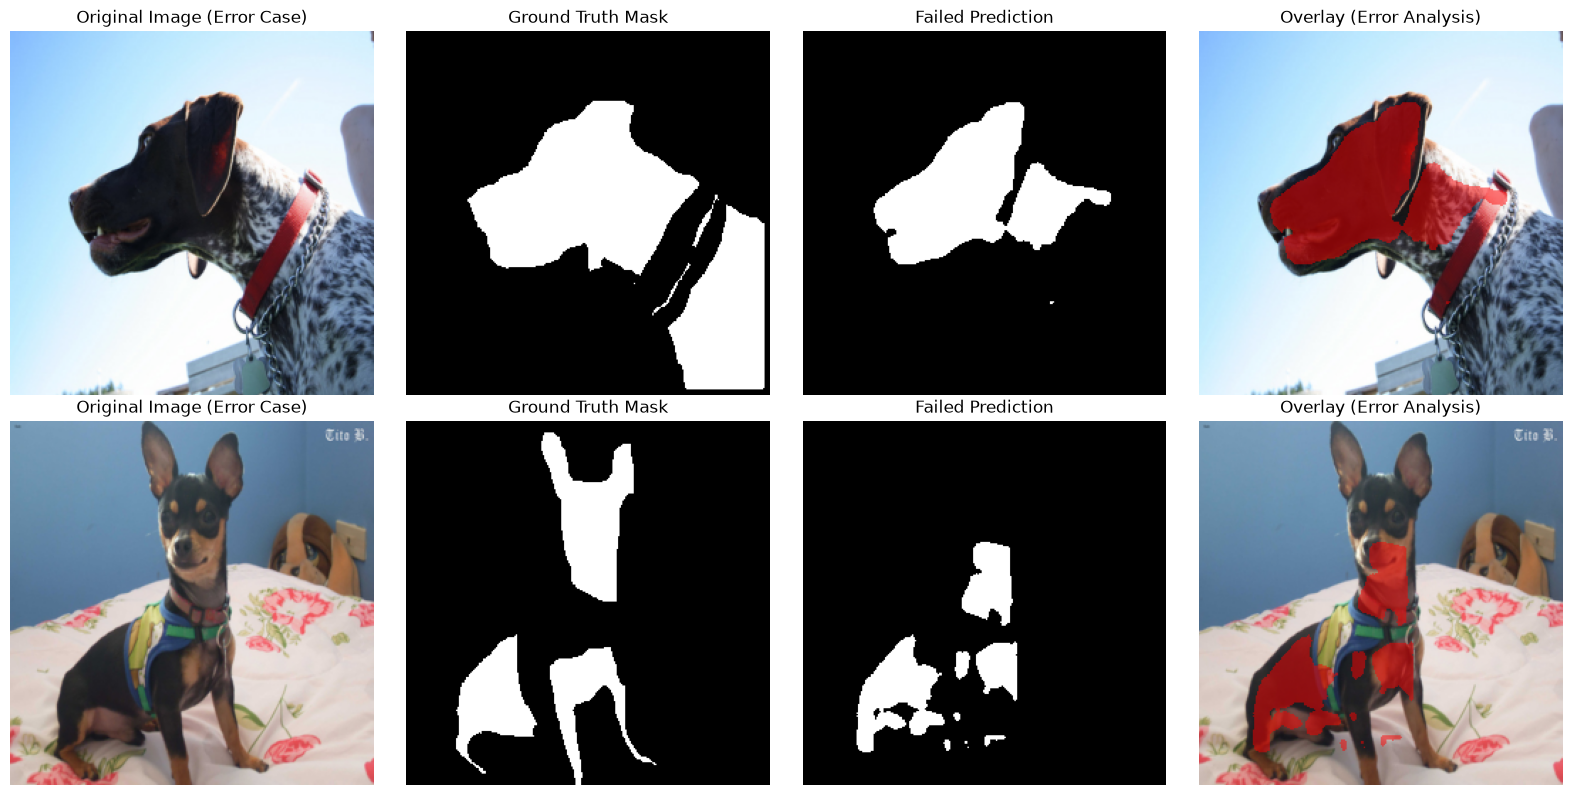

In [8]:
# Error Analysis (Samples with low IoU)
error_analysis(best_model, test_dataset, device=device, num_samples=2)
plt.show()

## Task 11, 12, 13: Segment Anything Model (SAM) Evaluation
Evaluate the zero-shot capabilities of SAM on our test dataset. It downloads the SAM weights (if needed) and generates masks. Since SAM extracts all prominent objects, we calculate metrics against the ground truth to find the best matching mask.


--- Task 11: Loading SAM Model ---
Loading test dataset...

--- Task 12 & 13: Generating Masks and Finding Best Match ---
Processing image 1/3...
Processing image 2/3...
Processing image 3/3...

--- Task 13: SAM Quantitative Results ---
Mean IoU of Best SAM Masks: 0.3038
Mean Dice of Best SAM Masks: 0.3430
Saved SAM evaluation visualization to 'task13_sam_evaluation.png'


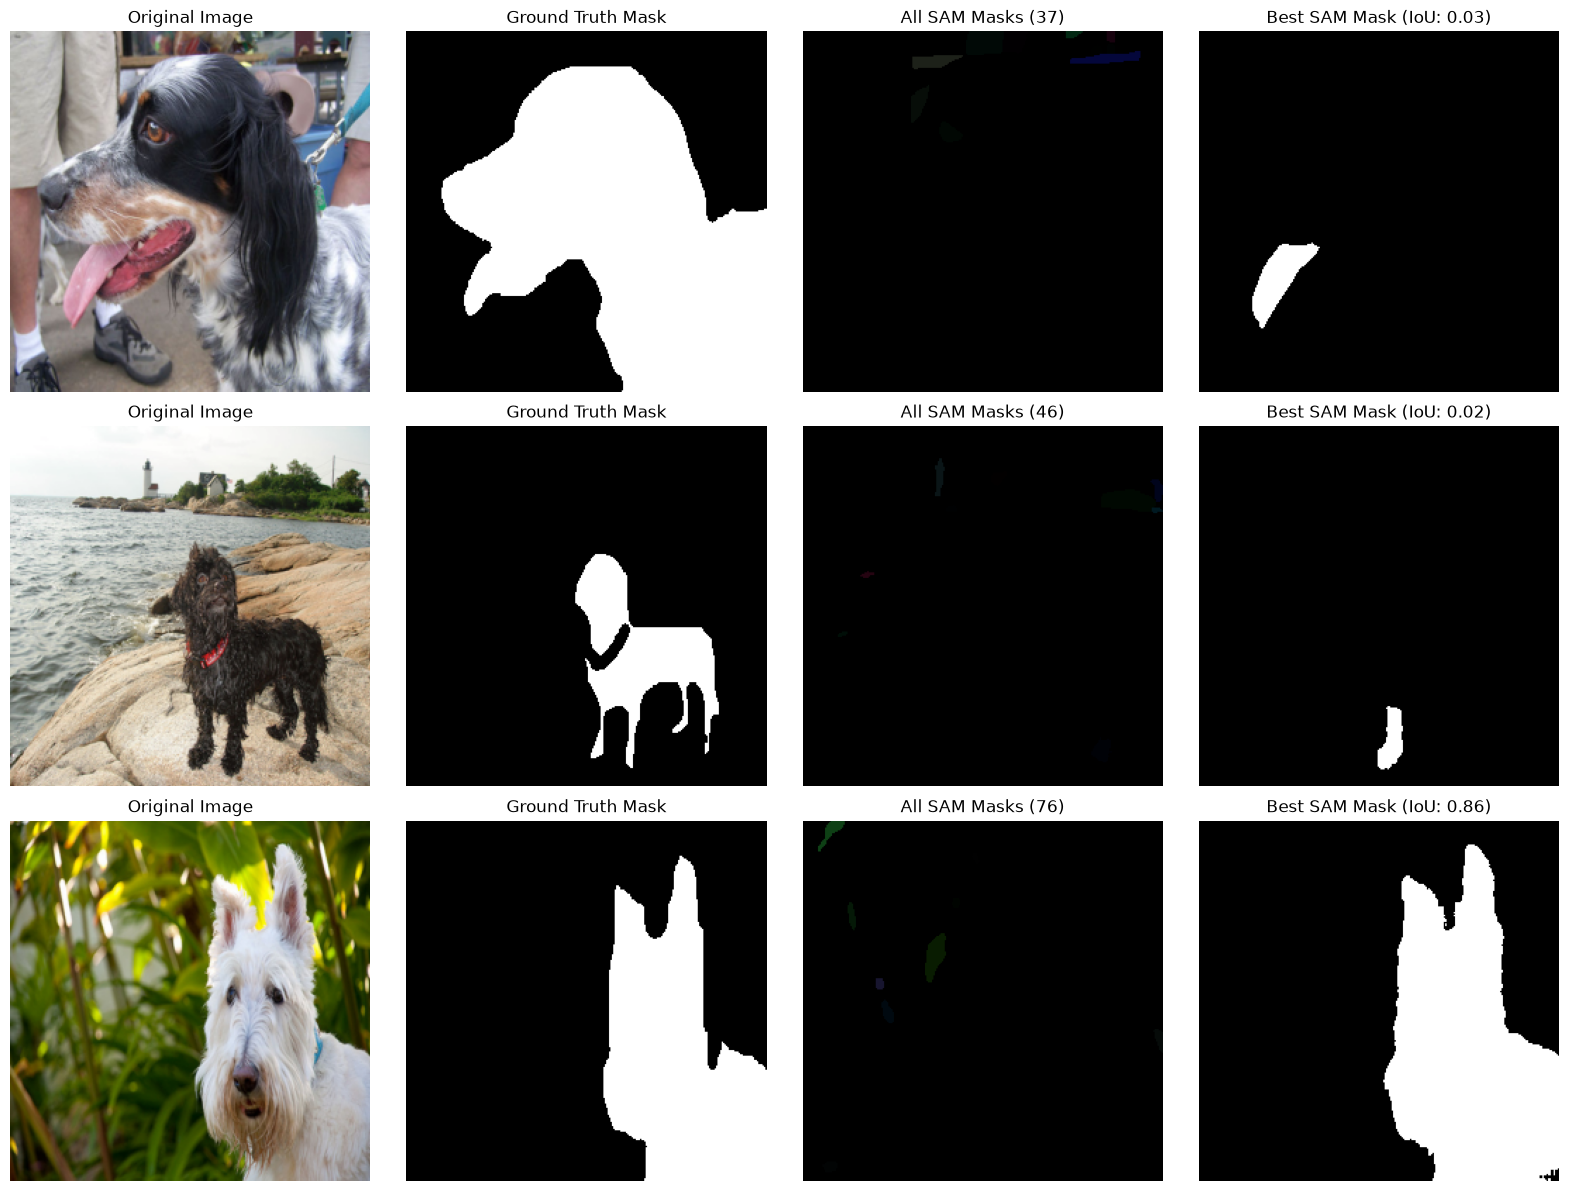

In [9]:
evaluate_sam_zero_shot(num_samples=3, device=device)
plt.show()

## Task 14, 15: Model Comparison (U-Net vs. SAM)
Perform a direct comparison between the fully-supervised U-Net and the zero-shot SAM across a subset of the test data.

Loading test dataset...

Loading U-Net Model...
U-Net loaded successfully.

Loading SAM Model (Zero-Shot)...

=== Experiment A: Qualitative Comparison ===

Running Evaluation (Qualitative and Quantitative)...
Evaluating 20 samples
Processed 20/20...

Qualitative plot generated!
Saved qualitative comparison to 'task15_model_comparison_qualitative.png'

=== Experiment B: Quantitative Comparison ===

Model           | Mean IoU     | Mean Dice Score
--------------------------------------------------
U-Net           | 0.6276       | 0.7524         
SAM (Zero-Shot) | 0.2788       | 0.3654         


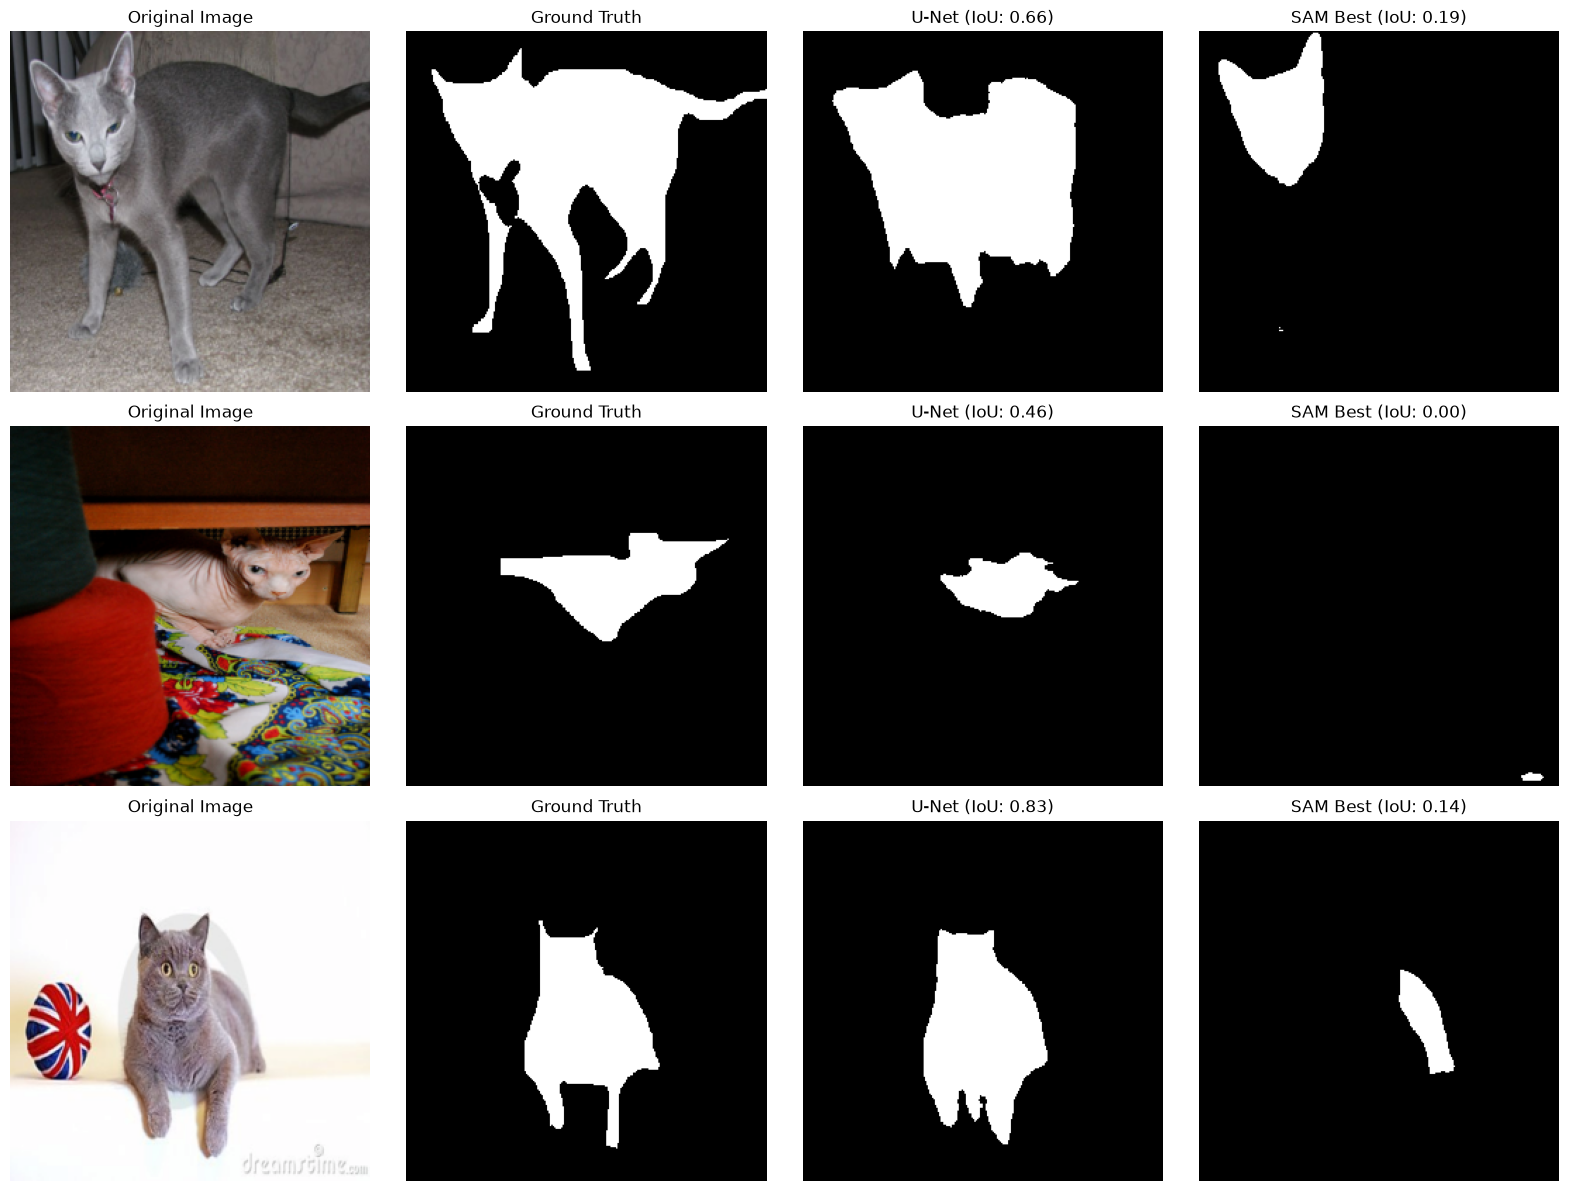

In [10]:
# Running quantitative comparison on 20 samples to save time (SAM is computationally heavy without specialized optimizations).
# It will also generate a qualitative side-by-side plot for 3 samples.
compare_models(num_qualitative_samples=3, num_quantitative_samples=20, device=device)
plt.show()